In [60]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/iris/Iris.csv
/kaggle/input/iris/database.sqlite


## Iris Dataset
The Iris dataset features measurements of 150 iris flowers across three species of setosa, versicolor, and virginica.

In [61]:
import pandas as pd
import numpy as np
df = pd.read_csv("/kaggle/input/iris/Iris.csv")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


## What are sepal and Petal?

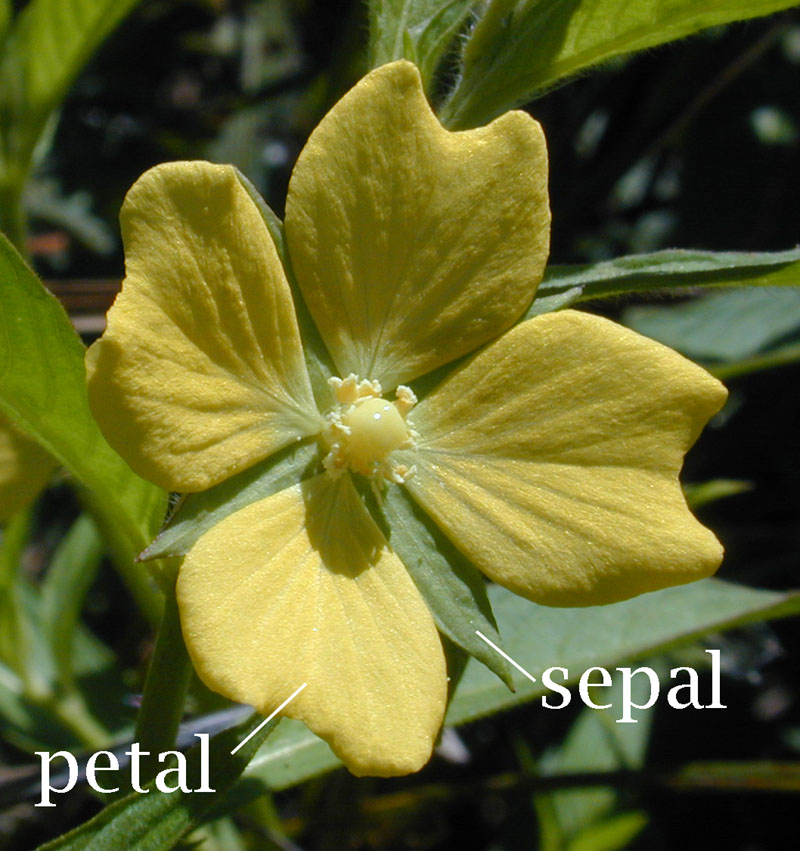
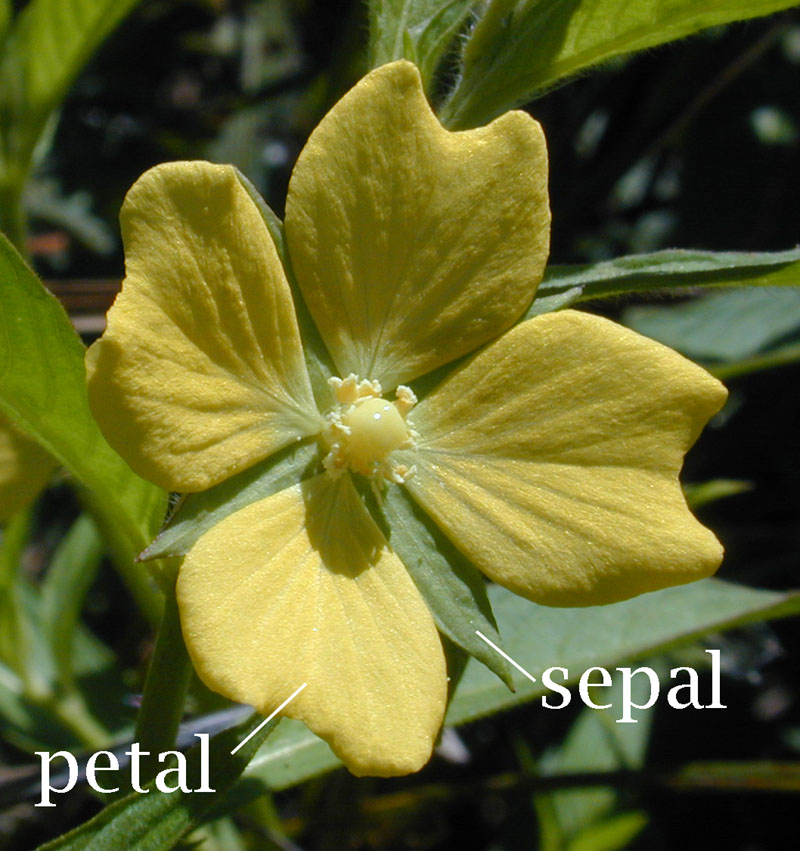

### Whats the objective

Based on the data and the columns, the objective of this project is to predict the species based on the features.


In [62]:
### EDA
print(df.info())

print(df.describe())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None
               Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count  150.000000     150.000000    150.000000     150.000000    150.000000
mean    75.500000       5.843333      3.054000       3.758667      1.198667
std     43.445368       0.828066      0.433594       1.764420      0.763161
min      1.000000       4.300000      2.000000       1.000000      0.100000
25%     38.250000       5.100000      2.800000       1.600000      0.300000
50%     75.500000    

                         SepalLengthCm  SepalWidthCm  PetalLengthCm  \
SepalLengthCm                 1.000000     -0.109369       0.871754   
SepalWidthCm                 -0.109369      1.000000      -0.420516   
PetalLengthCm                 0.871754     -0.420516       1.000000   
PetalWidthCm                  0.817954     -0.356544       0.962757   
Species_Iris-setosa          -0.717416      0.595601      -0.922688   
Species_Iris-versicolor       0.079396     -0.464700       0.201587   
Species_Iris-virginica        0.638020     -0.130901       0.721102   

                         PetalWidthCm  Species_Iris-setosa  \
SepalLengthCm                0.817954            -0.717416   
SepalWidthCm                -0.356544             0.595601   
PetalLengthCm                0.962757            -0.922688   
PetalWidthCm                 1.000000            -0.887510   
Species_Iris-setosa         -0.887510             1.000000   
Species_Iris-versicolor      0.118376            -0.500000 

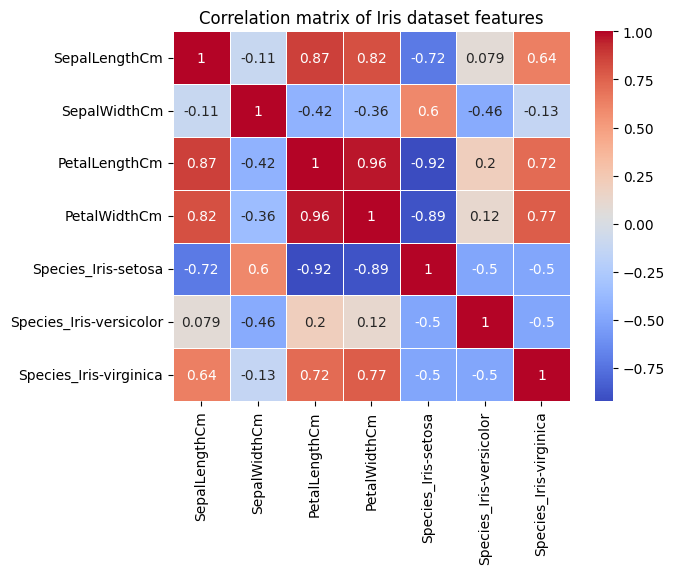

In [63]:
### Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# use one hot encoder to encode species

df_encoded = pd.get_dummies(df, columns=['Species'], prefix='Species')
df_encoded = df_encoded.drop('Id', axis = 1)
correlation_matrix = df_encoded.corr()
print(correlation_matrix)

sns.heatmap(correlation_matrix, annot=True, cmap = "coolwarm", linewidth = 0.5)
plt.title("Correlation matrix of Iris dataset features")
plt.show()

### Analysis and intuition

Based on the correlation matrix, we can see that there's a moderate positive correlation between Sepal Length and Virginica.
The same can be said about Petal length and Petal width. 
Another thing that we can observe is that Petal Width is Correlated with Petal length. There's also a strong correlation between Sepal Length and Petal Width

### Model training
In this phase, I'm going to test a basic model on the dataset to get an intution about it.
I'm going to split the dataset into train and test sets, and then I'm going to train and evaluate the model.

For this part, I'm going to use Support Vector Machine model. So I still stick to One Hot encoder.

In [64]:
# preparing sets
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=[col for col in df_encoded.columns if col.startswith('Species_')])
y = df_encoded[[col for col in df_encoded.columns if col.startswith('Species_')]]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=5)
y.head()

,Species_Iris-setosa,Species_Iris-versicolor,Species_Iris-virginica
0,True,False,False
1,True,False,False
2,True,False,False
3,True,False,False
4,True,False,False


In [65]:
# training the model
from sklearn.svm import SVC
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score, classification_report

svm = SVC(probability=True)  # probability=True is required for multi-output
multi_target_svm = MultiOutputClassifier(svm, n_jobs=-1)
multi_target_svm.fit(X_train, y_train)


MultiOutputClassifier(estimator=SVC(probability=True), n_jobs=-1)

In [66]:
# model evaluation
y_pred = multi_target_svm.predict(X_test)

# Convert predictions to DataFrame for easier handling
y_pred_df = pd.DataFrame(y_pred, columns=y.columns, index=y_test.index)

print("First few predictions:")
print(y_pred_df.head())

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred_df)
print(f"\nAccuracy: {accuracy:.2f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_df))

First few predictions:
     Species_Iris-setosa  Species_Iris-versicolor  Species_Iris-virginica
82                 False                     True                   False
134                False                    False                    True
114                False                    False                    True
42                  True                    False                   False
109                False                    False                    True

Accuracy: 0.90

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       0.85      1.00      0.92        11
           2       0.92      1.00      0.96        11

   micro avg       0.91      1.00      0.95        30
   macro avg       0.92      1.00      0.96        30
weighted avg       0.91      1.00      0.95        30
 samples avg       0.95      1.00      0.97        30



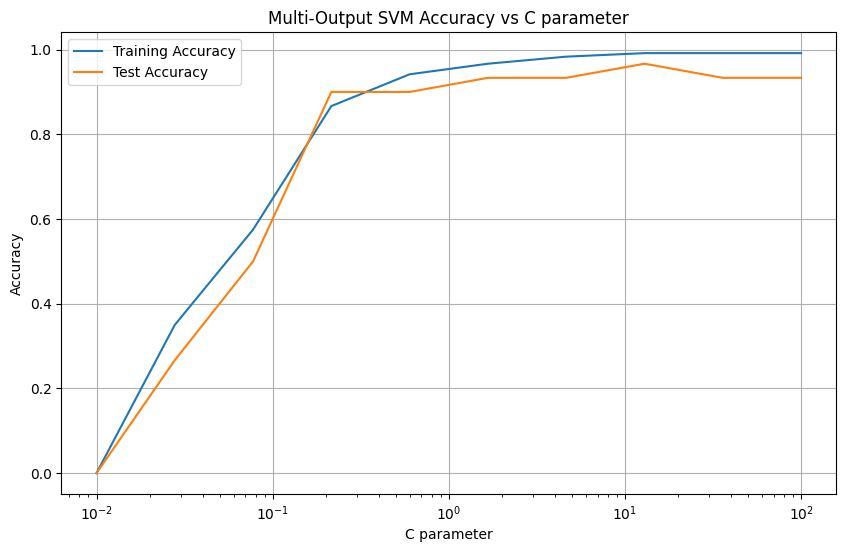

Best C value: 12.9155
Best training accuracy: 0.9917
Best test accuracy: 0.9667


In [67]:
# tweaking the model
# Define range of C values to test
C_range = np.logspace(-2, 2, 10)

# Lists to store accuracy scores
train_scores = []
test_scores = []

# Perform training and evaluation for each C value
for C in C_range:
    # Create and train the multi-output SVM model
    svm = SVC(C=C, kernel='rbf', probability=True, random_state=5)
    multi_target_svm = MultiOutputClassifier(svm, n_jobs=-1)
    multi_target_svm.fit(X_train, y_train)
    
    y_train_pred = multi_target_svm.predict(X_train)
    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_scores.append(train_accuracy)
    
    # Make predictions and calculate accuracy for test data
    y_test_pred = multi_target_svm.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_scores.append(test_accuracy)

# Plot the results
plt.figure(figsize=(10, 6))
plt.semilogx(C_range, train_scores, label='Training Accuracy')
plt.semilogx(C_range, test_scores, label='Test Accuracy')
plt.xlabel('C parameter')
plt.ylabel('Accuracy')
plt.title('Multi-Output SVM Accuracy vs C parameter')
plt.legend()
plt.grid(True)
plt.show()

# Print the best C value and corresponding accuracies
best_C_index = np.argmax(test_scores)
best_C = C_range[best_C_index]
print(f"Best C value: {best_C:.4f}")
print(f"Best training accuracy: {train_scores[best_C_index]:.4f}")
print(f"Best test accuracy: {test_scores[best_C_index]:.4f}")

### Testing other models and fine tune them

In this step, I'm going to use other models, as well as fine tunning them using GridSearchCV

In [71]:
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
RANDOM_STATE = 6

# Define models and their parameter grids
models = {
    'SVM': (MultiOutputClassifier(SVC(probability=True, random_state=RANDOM_STATE)),
            {'model__estimator__C': [0.1, 1, 1.6681, 10],
             'model__estimator__kernel': ['rbf', 'linear'],
             'model__estimator__gamma': ['scale', 'auto']}),
    
    'Random Forest': (MultiOutputClassifier(RandomForestClassifier(random_state=RANDOM_STATE)),
                      {'model__estimator__n_estimators': [50, 100, 200],
                       'model__estimator__max_depth': [None, 10, 20],
                       'model__estimator__min_samples_split': [2, 5, 10]}),
    
    'Gradient Boosting': (MultiOutputClassifier(GradientBoostingClassifier(random_state=RANDOM_STATE)),
                          {'model__estimator__n_estimators': [50, 100, 200],
                           'model__estimator__learning_rate': [0.01, 0.1, 0.2],
                           'model__estimator__max_depth': [3, 5, 7]}),
    
    'XGBoost': (MultiOutputClassifier(XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=RANDOM_STATE)),
                {'model__estimator__n_estimators': [50, 100, 200],
                 'model__estimator__learning_rate': [0.01, 0.1, 0.3],
                 'model__estimator__max_depth': [3, 5, 7],
                 'model__estimator__min_child_weight': [1, 3, 5]})
}

# Dictionary to store results
results = {}

# Perform grid search for each model
for name, (model, param_grid) in models.items():
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    
    grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    
    # Make predictions
    y_pred = grid_search.predict(X_test)
    
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    
    # Store results
    results[name] = {
        'best_params': grid_search.best_params_,
        'best_score': grid_search.best_score_,
        'test_accuracy': accuracy,
        'model': grid_search.best_estimator_
    }
    
    print(f"\n{name} Results:")
    print(f"Best parameters: {grid_search.best_params_}")
    print(f"Best cross-validation score: {grid_search.best_score_:.4f}")
    print(f"Test accuracy: {accuracy:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))




SVM Results:
Best parameters: {'model__estimator__C': 1, 'model__estimator__gamma': 'scale', 'model__estimator__kernel': 'rbf'}
Best cross-validation score: 0.9667
Test accuracy: 0.9333

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       0.91      0.91      0.91        11
           2       0.91      0.91      0.91        11

   micro avg       0.93      0.93      0.93        30
   macro avg       0.94      0.94      0.94        30
weighted avg       0.93      0.93      0.93        30
 samples avg       0.93      0.93      0.93        30


Random Forest Results:
Best parameters: {'model__estimator__max_depth': None, 'model__estimator__min_samples_split': 2, 'model__estimator__n_estimators': 50}
Best cross-validation score: 0.9583
Test accuracy: 0.9000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
    

/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))



XGBoost Results:
Best parameters: {'model__estimator__learning_rate': 0.01, 'model__estimator__max_depth': 3, 'model__estimator__min_child_weight': 3, 'model__estimator__n_estimators': 100}
Best cross-validation score: 0.9417
Test accuracy: 0.9000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       0.83      0.91      0.87        11
           2       0.90      0.82      0.86        11

   micro avg       0.90      0.90      0.90        30
   macro avg       0.91      0.91      0.91        30
weighted avg       0.90      0.90      0.90        30
 samples avg       0.90      0.90      0.90        30



In [69]:
# Identify the best model
best_model = max(results, key=lambda x: results[x]['test_accuracy'])
print(f"\nBest Model: {best_model}")
print(f"Best Model Test Accuracy: {results[best_model]['test_accuracy']:.4f}")

# Use the best model for final predictions
best_model_pipeline = results[best_model]['model']
final_predictions = best_model_pipeline.predict(X_test)

print("\nFinal Classification Report:")
print(classification_report(y_test, final_predictions))


Best Model: SVM
Best Model Test Accuracy: 0.9333

Final Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       0.91      0.91      0.91        11
           2       0.91      0.91      0.91        11

   micro avg       0.93      0.93      0.93        30
   macro avg       0.94      0.94      0.94        30
weighted avg       0.93      0.93      0.93        30
 samples avg       0.93      0.93      0.93        30



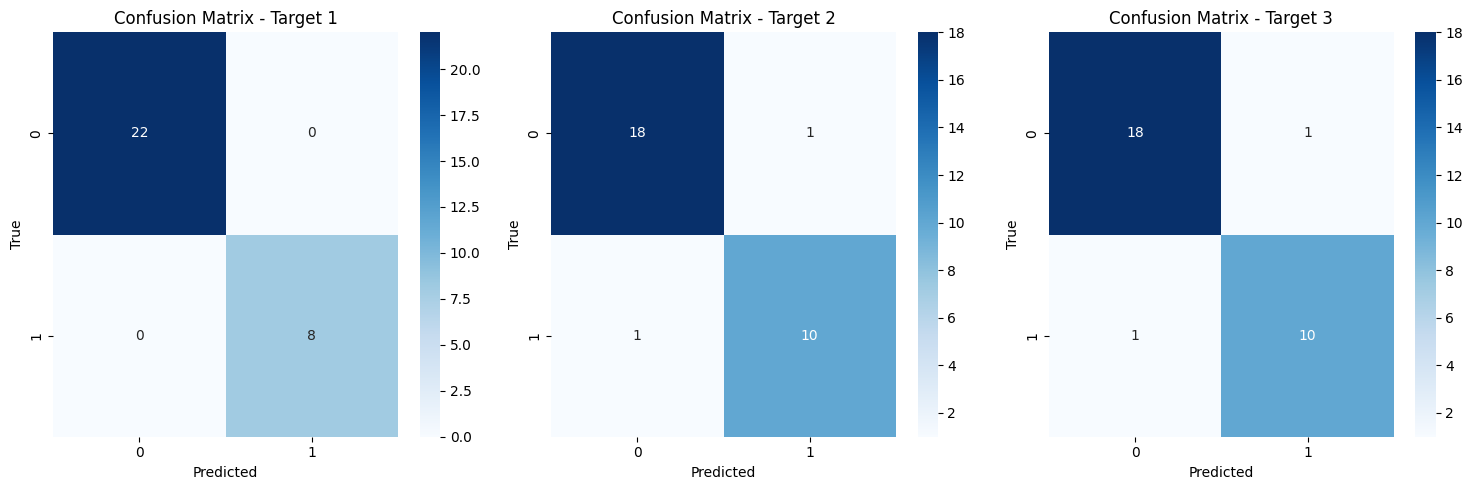


SVM Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       0.91      0.91      0.91        11
           2       0.91      0.91      0.91        11

   micro avg       0.93      0.93      0.93        30
   macro avg       0.94      0.94      0.94        30
weighted avg       0.93      0.93      0.93        30
 samples avg       0.93      0.93      0.93        30



In [72]:
from sklearn.metrics import confusion_matrix

import seaborn as sns


best_svm_model = results['SVM']['model']

# Make predictions using the best SVM model
y_pred_svm = best_svm_model.predict(X_test)

y_test_np = y_test.values if isinstance(y_test, pd.DataFrame) else y_test
y_pred_svm_np = y_pred_svm if isinstance(y_pred_svm, np.ndarray) else y_pred_svm.values

# Get the number of target variables
n_targets = y_test_np.shape[1] if len(y_test_np.shape) > 1 else 1

# Create confusion matrix plots for each target variable
fig, axes = plt.subplots(1, n_targets, figsize=(5*n_targets, 5))
axes = [axes] if n_targets == 1 else axes

for i in range(n_targets):
    if n_targets == 1:
        cm = confusion_matrix(y_test_np, y_pred_svm_np)
    else:
        cm = confusion_matrix(y_test_np[:, i], y_pred_svm_np[:, i])
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f'Confusion Matrix - Target {i+1}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('True')

plt.tight_layout()
plt.show()

print("\nSVM Classification Report:")
print(classification_report(y_test_np, y_pred_svm_np))

if hasattr(best_svm_model.named_steps['model'].estimators_[0], 'coef_'):
    feature_importance = np.abs(best_svm_model.named_steps['model'].estimators_[0].coef_[0])
    feature_names = X_train.columns if isinstance(X_train, pd.DataFrame) else [f'Feature {i}' for i in range(X_train.shape[1])]
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x=feature_importance, y=feature_names)
    plt.title('SVM Feature Importance (Linear Kernel)')
    plt.xlabel('Absolute Coefficient Value')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()